## **Analisis temporal**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [2]:
USUARIO = "postgres"
PASSWORD = "1028"
HOST = "localhost"
PUERTO = "5432"
BASE_DATOS = "dw_analisis_criminalidad"

engine = create_engine(
    f"postgresql+psycopg2://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}"
)

print("Conexión creada correctamente.")

Conexión creada correctamente.


### **1. Evolucion general de la criminalidad**

In [7]:
query_evolucion_general = """
SELECT
    t.anio,
    SUM(f.cantidad_delitos) AS total_afectados
FROM fact_delitos f
INNER JOIN dim_tiempo t
    ON f.id_tiempo = t.id_tiempo
WHERE t.anio BETWEEN 2014 AND 2024
GROUP BY t.anio
ORDER BY t.anio;
"""

"""
SELECT
    t.anio,
    SUM(f.cantidad_afectados) AS total_afectados
FROM fact_afectaciones f
INNER JOIN dim_tiempo t
    ON f.id_tiempo = t.id_tiempo
WHERE t.anio BETWEEN 2014 AND 2024
GROUP BY t.anio
ORDER BY t.anio;
"""

df_evolucion_general = pd.read_sql(query_evolucion_general, engine)
df_evolucion_general.head(20)


,anio,total_afectados
0,2014,29880
1,2015,42580
2,2016,55225
3,2017,58002
4,2018,63099
5,2019,63963
6,2020,52563
7,2021,56575
8,2022,57850
9,2023,60932


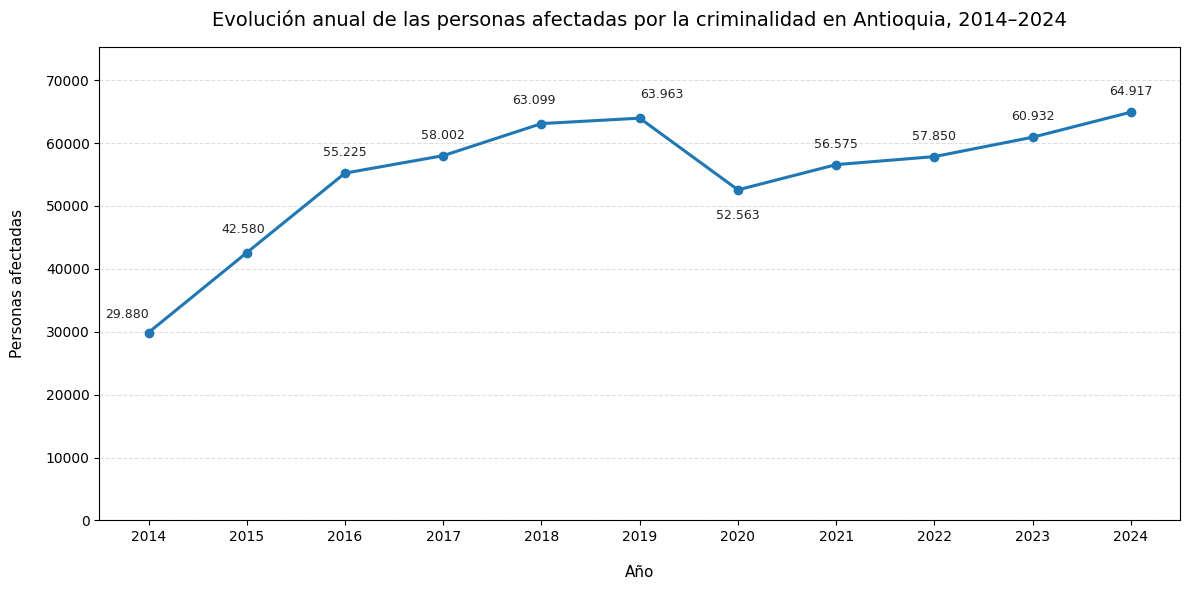

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Línea principal
plt.plot(
    df_evolucion_general["anio"],
    df_evolucion_general["total_afectados"],
    marker="o",
    linewidth=2.2,
    color="#1f77b4",
    zorder=3
)

# ==========================================================
# ETIQUETAS CON POSICIÓN PERSONALIZADA (una por una)
# ==========================================================

# Diccionario: año → (offset_x, offset_y, ha, va)
# offset en puntos (positivo = derecha/arriba)
offsets = {
    2014: (0,  8, "right",  "bottom"),
    2015: (  -18, 12, "left", "bottom"),
    2016: (  0, 10, "center", "bottom"),
    2017: (  0, 10, "center", "bottom"),
    2018: (10, 12, "right",  "bottom"),   # separamos 2018 y 2019
    2019: ( 0, 12, "left",   "bottom"),
    2020: (  0, -14, "center", "top"),     # debajo porque baja
    2021: (  0, 10, "center", "bottom"),
    2022: (  0, 10, "center", "bottom"),
    2023: (  0, 10, "center", "bottom"),
    2024: (  0, 10, "center", "bottom"),
}

for x, y in zip(df_evolucion_general["anio"], df_evolucion_general["total_afectados"]):
    dx, dy, ha, va = offsets[x]
    
    plt.annotate(
        f"{y:,.0f}".replace(",", "."),
        (x, y),
        textcoords="offset points",
        xytext=(dx, dy),
        ha=ha,
        va=va,
        fontsize=9,
        color="#222222",
        zorder=5
    )

# ==========================================================
# TÍTULO Y EJES
# ==========================================================
plt.title(
    "Evolución anual de las personas afectadas por la criminalidad en Antioquia, 2014–2024",
    fontsize=14,
    pad=15
)

plt.xlabel("Año", fontsize=11, labelpad=15)
plt.ylabel("Personas afectadas", fontsize=11, labelpad=15)

plt.xticks(df_evolucion_general["anio"])
plt.ticklabel_format(style="plain", axis="y")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Espacio suficiente arriba y abajo
ymax = df_evolucion_general["total_afectados"].max()
plt.ylim(0, ymax * 1.16)

plt.tight_layout()

### **2. Evolucion temporal por tipo de delito**

In [ ]:
query = """
SELECT
    t.anio,
    d.tipo_delito,
    SUM(f.cantidad_delitos) AS total_afectados
FROM fact_delitos f
INNER JOIN dim_tiempo t
    ON f.id_tiempo = t.id_tiempo
INNER JOIN dim_delito d
    ON f.id_delito = d.id_delito
WHERE t.anio BETWEEN 2014 AND 2024
GROUP BY
    t.anio,
    d.tipo_delito
ORDER BY
    t.anio,
    d.tipo_delito;
"""

"""
SELECT
    t.anio,
    d.tipo_delito,
    SUM(f.cantidad_afectados) AS total_afectados
FROM fact_afectaciones f
INNER JOIN dim_tiempo t
    ON f.id_tiempo = t.id_tiempo
INNER JOIN dim_delito d
    ON f.id_delito = d.id_delito
WHERE t.anio BETWEEN 2014 AND 2024
GROUP BY t.anio, d.tipo_delito
ORDER BY t.anio, d.tipo_delito;
"""

df_evolucion_tipos = pd.read_sql(query, engine)
df_evolucion_tipos.head()


,anio,tipo_delito,total_afectados
0,2014,Amenazas,2071
1,2014,Delitos sexuales,886
2,2014,Homicidio,1971
3,2014,Hurto a residencias y entidades comerciales,2298
4,2014,Hurto de motocicletas y automotores,7453


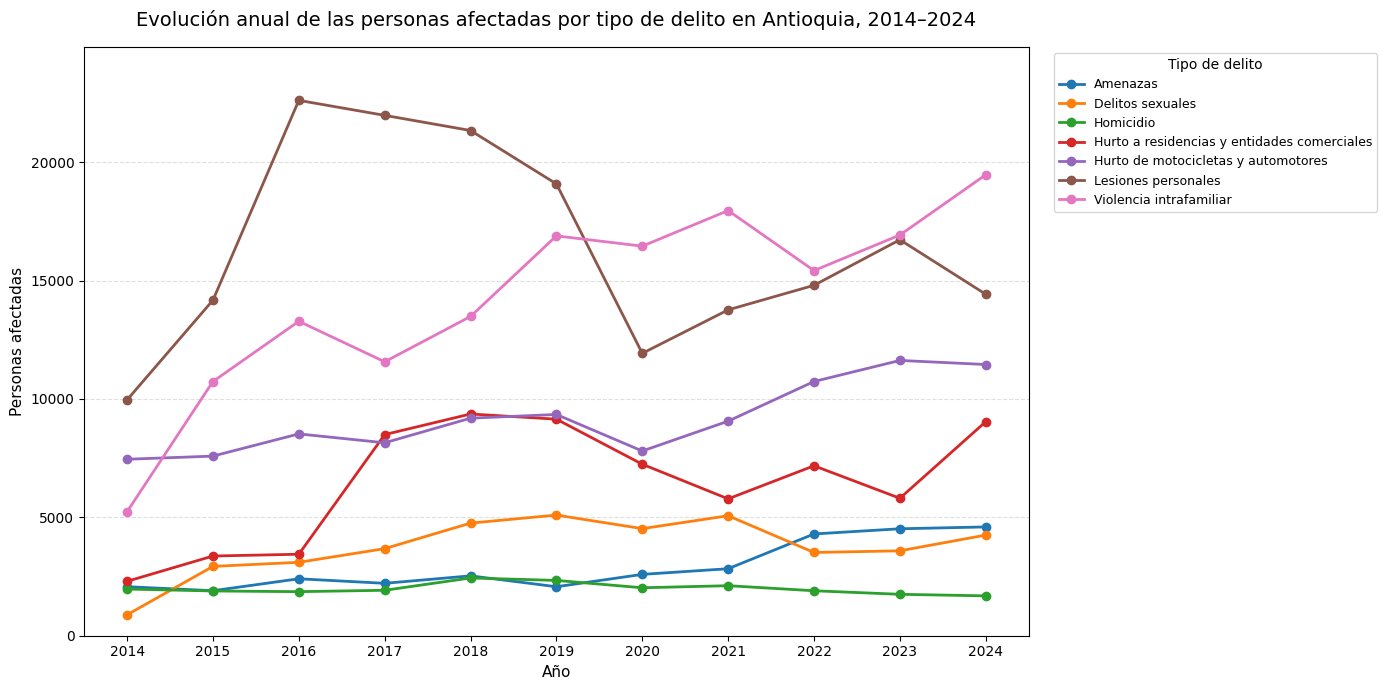

In [31]:
import matplotlib.pyplot as plt

# ==========================================================
# ORDEN DE LOS DELITOS
# ==========================================================

orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

# ==========================================================
# GRÁFICA
# ==========================================================

plt.figure(figsize=(14, 7))

for delito in orden_delitos:

    datos = df_evolucion_tipos[
        df_evolucion_tipos["tipo_delito"] == delito
    ].sort_values("anio")

    plt.plot(
        datos["anio"],
        datos["total_afectados"],
        marker="o",
        linewidth=2,
        label=delito
    )

# ==========================================================
# FORMATO
# ==========================================================

plt.title(
    "Evolución anual de las personas afectadas por tipo de delito "
    "en Antioquia, 2014–2024",
    fontsize=14,
    pad=15
)

plt.xlabel("Año", fontsize=11)
plt.ylabel("Personas afectadas", fontsize=11)

plt.xticks(
    range(2014, 2025),
    fontsize=10
)

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.ylim(
    0,
    df_evolucion_tipos["total_afectados"].max() * 1.10
)

plt.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12572\3467219381.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


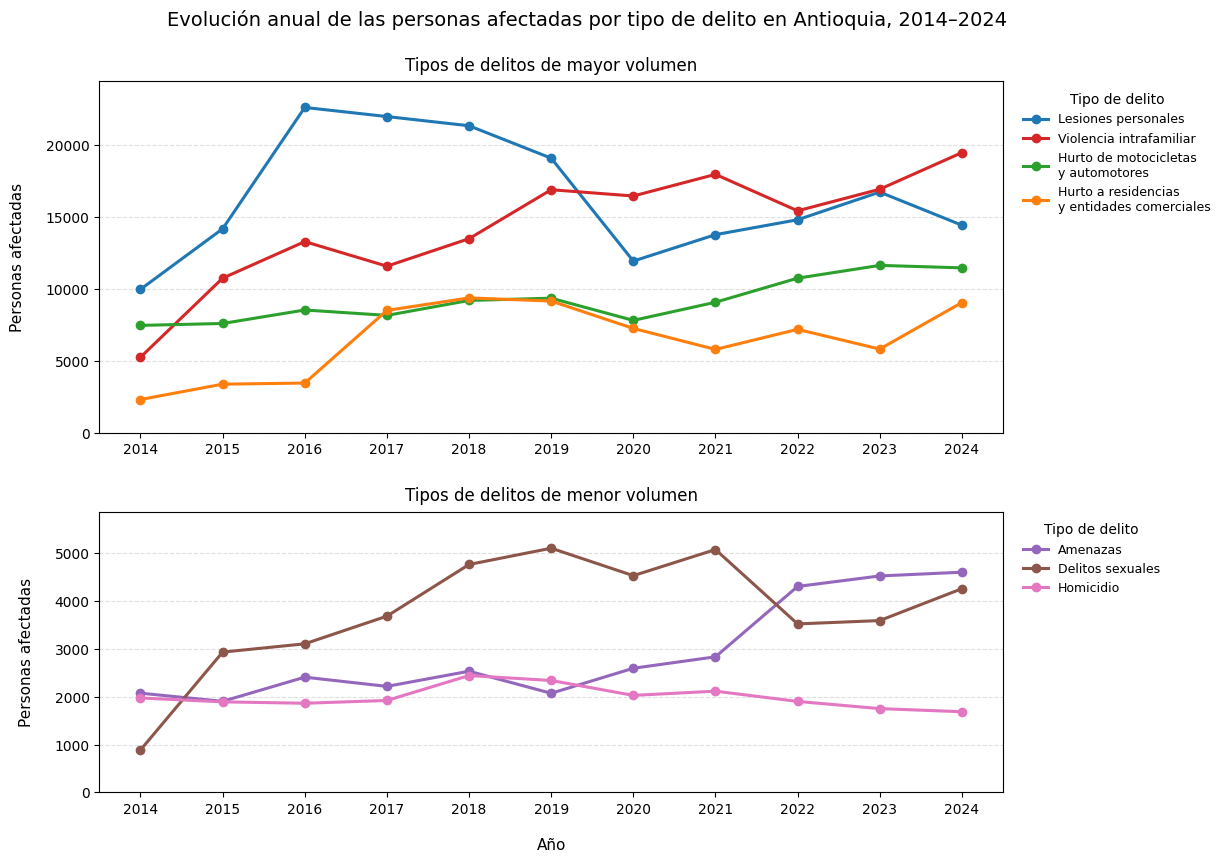

In [41]:
import matplotlib.pyplot as plt

# ==========================================================
# GRUPOS DE DELITOS (con saltos de línea en los nombres largos)
# ==========================================================

delitos_altos = [
    "Lesiones personales",
    "Violencia intrafamiliar",
    "Hurto de motocicletas\ny automotores",
    "Hurto a residencias\ny entidades comerciales"
]

delitos_bajos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio"
]

# ==========================================================
# COLORES
# ==========================================================

colores = {
    "Lesiones personales": "#1f77b4",
    "Violencia intrafamiliar": "#d62728",
    "Hurto de motocicletas\ny automotores": "#2ca02c",
    "Hurto a residencias\ny entidades comerciales": "#ff7f0e",
    "Amenazas": "#9467bd",
    "Delitos sexuales": "#8c564b",
    "Homicidio": "#e377c2"
}

# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(13, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1], "hspace": 0.25}  # un poco más de espacio
)

# ----------------------------------------------------------
# PANEL SUPERIOR
# ----------------------------------------------------------
for delito in delitos_altos:
    delito_filtro = delito.replace("\n", " ")
    
    datos = df_evolucion_tipos[
        df_evolucion_tipos["tipo_delito"] == delito_filtro
    ].sort_values("anio")

    ax1.plot(
        datos["anio"],
        datos["total_afectados"],
        marker="o",
        linewidth=2.2,
        color=colores[delito],
        label=delito
    )

ax1.set_title("Tipos de delitos de mayor volumen", fontsize=12, pad=8)
ax1.set_ylabel("Personas afectadas", fontsize=11, labelpad=15)
ax1.ticklabel_format(style="plain", axis="y")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.set_ylim(0, df_evolucion_tipos["total_afectados"].max() * 1.08)

# ← Aquí se fuerzan los años en el panel superior
ax1.set_xticks(range(2014, 2025))
ax1.tick_params(axis="x", labelbottom=True)

ax1.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    frameon=False
)

# ----------------------------------------------------------
# PANEL INFERIOR
# ----------------------------------------------------------
for delito in delitos_bajos:
    datos = df_evolucion_tipos[
        df_evolucion_tipos["tipo_delito"] == delito
    ].sort_values("anio")

    ax2.plot(
        datos["anio"],
        datos["total_afectados"],
        marker="o",
        linewidth=2.2,
        color=colores[delito],
        label=delito
    )

ax2.set_title("Tipos de delitos de menor volumen", fontsize=12, pad=8)
ax2.set_xlabel("Año", fontsize=11, labelpad=15)
ax2.set_ylabel("Personas afectadas", fontsize=11, labelpad=15)
ax2.ticklabel_format(style="plain", axis="y")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

max_bajos = df_evolucion_tipos[
    df_evolucion_tipos["tipo_delito"].isin(delitos_bajos)
]["total_afectados"].max()
ax2.set_ylim(0, max_bajos * 1.15)

ax2.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    frameon=False
)

# ----------------------------------------------------------
# FORMATO GENERAL
# ----------------------------------------------------------
fig.suptitle(
    "Evolución anual de las personas afectadas por tipo de delito en Antioquia, 2014–2024",
    fontsize=14,
    y=0.98
)

ax2.set_xticks(range(2014, 2025))
ax2.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.90, right=0.82)
plt.show()